# MVP - Machine Learning & Analytics

## Previsão de Preços de Imóveis utilizando Machine Learning

**Aluno:** Mirela Athayde

**Disciplina:** Machine Learning & Analytics

**Sprint:** MVP Final

**Tipo de Problema:** Regressão Supervisionada

### Objetivo

Desenvolver um modelo de Machine Learning capaz de prever o preço de venda de imóveis com base em características físicas, estruturais e locacionais das propriedades, avaliando e comparando diferentes algoritmos de regressão para identificar a solução com melhor desempenho preditivo.


## Fonte dos Dados

O dataset utilizado neste trabalho foi obtido a partir da competição **House Prices: Advanced Regression Techniques**, disponibilizada publicamente na plataforma Kaggle.

**Dataset original:**
https://www.kaggle.com/datasets/rishitaverma02/house-prices-advanced-regression-techniques?resource=download&select=train+%281%29.csv

A base contém informações sobre imóveis residenciais localizados na cidade de Ames, Iowa (Estados Unidos), incluindo atributos relacionados à qualidade da construção, área construída, características estruturais, localização e condições de venda.

Para garantir a reprodutibilidade do projeto e permitir a execução completa do notebook sem necessidade de uploads manuais, o dataset utilizado foi disponibilizado em um repositório público no GitHub e carregado diretamente por URL durante a execução do código.

**Repositório do projeto:**
https://github.com/athaydemirela/mvp-ml-house-prices

O conjunto de dados utilizado para treinamento contém 1.460 registros e 81 atributos originais, incluindo a variável alvo `SalePrice`, que representa o preço de venda do imóvel.

A escolha dessa base foi motivada pela sua ampla utilização em problemas de regressão supervisionada, pela diversidade de atributos disponíveis e pela adequação ao objetivo proposto neste MVP de previsão de preços imobiliários.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/athaydemirela/mvp-ml-house-prices/main/train.csv"

In [3]:
df = pd.read_csv(url)

In [4]:
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# MVP - Previsão de Preços de Imóveis

## Apresentação do Problema

Este trabalho tem como objetivo desenvolver um modelo de Machine Learning capaz de prever o preço de venda de imóveis com base em características estruturais, físicas e locacionais das propriedades.

O problema é tratado como uma tarefa de regressão supervisionada, pois o objetivo é estimar uma variável numérica contínua denominada SalePrice.

A base de dados utilizada contém informações sobre imóveis residenciais da cidade de Ames, Iowa (Estados Unidos), incluindo atributos como área construída, qualidade da construção, número de cômodos, localização e outras características relevantes.

A previsão de preços de imóveis possui aplicações práticas em avaliação imobiliária, concessão de crédito, investimentos e análise de mercado.

A variável alvo do modelo será SalePrice, que representa o preço final de venda do imóvel.

As principais premissas deste trabalho são que as características presentes na base possuem relação com o valor de venda dos imóveis e que os padrões observados nos dados históricos podem ser utilizados para estimar preços futuros.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Apresentação dos Dados

O dataset utilizado neste trabalho contém informações sobre imóveis residenciais comercializados na cidade de Ames, Iowa (Estados Unidos). A base possui 1.460 registros e 81 atributos, incluindo variáveis numéricas e categóricas relacionadas às características físicas, estruturais e locacionais dos imóveis.

A variável alvo do problema é `SalePrice`, que representa o preço final de venda do imóvel. Como o objetivo é prever um valor numérico contínuo, o problema é caracterizado como uma tarefa de regressão supervisionada.

A análise inicial mostrou que o dataset possui 38 variáveis numéricas e 43 variáveis categóricas. Além disso, algumas colunas apresentam valores ausentes, especialmente atributos relacionados a piscinas, cercas, vielas de acesso e características complementares dos imóveis.

Com relação à variável alvo, observou-se que os preços dos imóveis variam entre 34.900 e 755.000 dólares. O preço médio dos imóveis é de aproximadamente 180.921 dólares, enquanto a mediana é de 163.000 dólares. A diferença entre média e mediana sugere a presença de imóveis com valores muito elevados, que influenciam a distribuição dos preços.


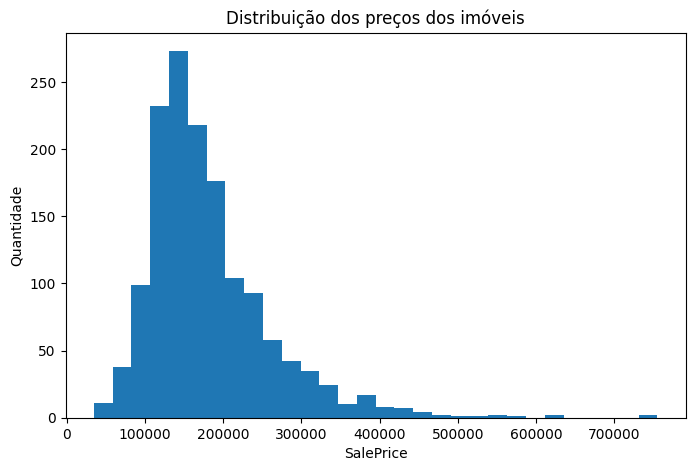

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['SalePrice'], bins=30)
plt.xlabel('SalePrice')
plt.ylabel('Quantidade')
plt.title('Distribuição dos preços dos imóveis')
plt.show()

### Distribuição da Variável Alvo

O histograma da variável `SalePrice` mostra que os preços dos imóveis não seguem uma distribuição perfeitamente normal. Observa-se uma concentração maior de imóveis na faixa entre aproximadamente 100.000 e 200.000 dólares, enquanto uma quantidade menor de imóveis apresenta valores significativamente mais elevados.

A distribuição apresenta assimetria positiva (cauda à direita), indicando a existência de imóveis de alto valor que ocorrem com menor frequência, mas exercem influência sobre a média dos preços. Esse comportamento é consistente com o observado nas estatísticas descritivas, nas quais a média do preço dos imóveis foi superior à mediana.

A presença dessa assimetria deve ser considerada durante a etapa de modelagem, uma vez que distribuições muito assimétricas podem afetar o desempenho de alguns algoritmos de regressão.


In [9]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0].head(15)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


### Análise de Valores Ausentes

A análise dos valores ausentes mostrou que algumas variáveis apresentam uma quantidade significativa de registros nulos. As colunas com maior volume de valores ausentes incluem `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType` e `FireplaceQu`.

Entretanto, a documentação do dataset indica que muitos desses valores ausentes não representam erros ou falhas de coleta. Em diversos casos, a ausência de informação significa simplesmente que o imóvel não possui determinada característica. Por exemplo, um valor ausente em `PoolQC` indica que o imóvel não possui piscina, enquanto valores ausentes em `Alley`, `Fence` e `FireplaceQu` indicam ausência dessas estruturas.

Essa distinção é importante para a etapa de preparação dos dados, pois diferentes estratégias de tratamento deverão ser adotadas dependendo do significado dos valores ausentes em cada variável.


In [10]:
correlation = df.corr(numeric_only=True)

correlation['SalePrice'].sort_values(ascending=False).head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


### Análise de Correlação

Foi realizada uma análise de correlação entre as variáveis numéricas e a variável alvo `SalePrice`. Os resultados indicaram que algumas características dos imóveis apresentam forte relação com o preço de venda.

As variáveis com maior correlação positiva com o preço foram:

* `OverallQual` (0,79): qualidade geral dos materiais e acabamento do imóvel;
* `GrLivArea` (0,71): área habitável acima do nível do solo;
* `GarageCars` (0,64): capacidade da garagem em número de veículos;
* `GarageArea` (0,62): área da garagem;
* `TotalBsmtSF` (0,61): área total do porão;
* `1stFlrSF` (0,61): área do primeiro andar.

Esses resultados sugerem que imóveis com melhor qualidade construtiva, maior área habitável e maior capacidade de garagem tendem a apresentar preços de venda mais elevados.

A variável `OverallQual` apresentou a maior correlação observada, indicando que a qualidade geral do imóvel pode ser um dos principais fatores explicativos do preço de venda.


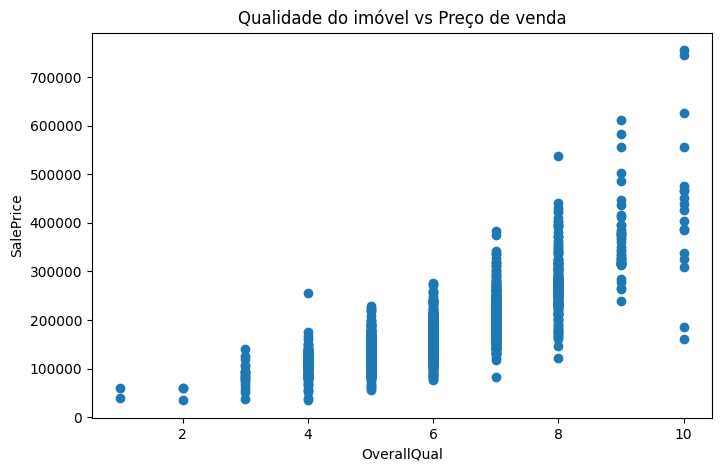

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(df['OverallQual'], df['SalePrice'])
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.title('Qualidade do imóvel vs Preço de venda')
plt.show()

### Relação entre Qualidade do Imóvel e Preço de Venda

O gráfico de dispersão entre `OverallQual` e `SalePrice` evidencia uma forte relação positiva entre a qualidade geral do imóvel e seu preço de venda.

Observa-se que imóveis com avaliações mais altas de qualidade tendem a apresentar preços significativamente maiores. Embora exista variabilidade dentro de cada faixa de qualidade, a tendência geral é clara: quanto melhor a qualidade construtiva e de acabamento do imóvel, maior tende a ser seu valor de mercado.

Esse comportamento é consistente com os resultados da análise de correlação, na qual `OverallQual` apresentou o maior coeficiente de correlação com a variável alvo. Dessa forma, essa variável surge como uma das mais relevantes para a construção dos modelos preditivos.


In [12]:
missing_pct = (df.isnull().sum() / len(df) * 100)

missing_pct[missing_pct > 0].sort_values(ascending=False).head(15)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


### Avaliação da Completude dos Dados

A análise percentual dos valores ausentes revelou que algumas variáveis apresentam níveis extremamente elevados de ausência de dados. As colunas `PoolQC`, `MiscFeature`, `Alley` e `Fence` possuem mais de 80% dos registros ausentes, indicando que essas características estão presentes apenas em uma pequena parcela dos imóveis.

Além disso, variáveis como `MasVnrType` e `FireplaceQu` também apresentam percentuais relevantes de valores ausentes. Conforme indicado na documentação da base, muitos desses valores ausentes representam a inexistência da característica no imóvel e não necessariamente falhas de coleta.

Para a etapa de preparação dos dados, serão adotadas estratégias distintas de tratamento. Variáveis com percentual muito elevado de ausência poderão ser removidas para simplificar o modelo, enquanto variáveis categóricas relacionadas à inexistência de características poderão receber uma categoria específica representando ausência da informação.


In [15]:
df_model = df.copy()

In [16]:
cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley']

df_model = df_model.drop(columns=cols_to_drop)

print(df_model.shape)

(1460, 78)


## Preparação dos Dados

### Remoção de Variáveis com Elevado Percentual de Valores Ausentes

A primeira etapa da preparação dos dados consistiu na avaliação das variáveis com maior percentual de valores ausentes.

As colunas `PoolQC`, `MiscFeature` e `Alley` apresentaram percentuais extremamente elevados de ausência, superiores a 90% dos registros. Embora, em muitos casos, esses valores ausentes representem a inexistência da característica no imóvel e não necessariamente erros de coleta, a quantidade reduzida de observações válidas limita significativamente seu potencial de contribuição para o modelo preditivo.

Considerando o objetivo deste MVP, optou-se pela remoção dessas variáveis. Essa decisão reduz a complexidade do processo de preparação dos dados, simplifica o tratamento de valores ausentes e mantém o foco em atributos com maior disponibilidade de informações.

A variável `Fence` também apresentou uma quantidade relevante de valores ausentes. Entretanto, como aproximadamente 19% dos registros possuem informações válidas para esse atributo, optou-se por mantê-la temporariamente na base para avaliação posterior durante as etapas de tratamento dos dados e modelagem.


In [17]:
missing_after_drop = (
    df_model.isnull()
            .sum()
            .sort_values(ascending=False)
)

missing_after_drop[missing_after_drop > 0]

,0
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageFinish,81
GarageYrBlt,81
GarageQual,81
GarageCond,81
GarageType,81
BsmtFinType2,38


### Estratégia de Tratamento dos Valores Ausentes

Após a remoção das variáveis com percentual extremamente elevado de ausência, foi realizada uma nova avaliação dos valores ausentes remanescentes.

Observou-se que grande parte das variáveis categóricas com valores ausentes está relacionada à inexistência de determinadas características no imóvel, como garagem, lareira, revestimento externo ou áreas acabadas no porão. Nesses casos, os valores ausentes não representam falhas de coleta, mas sim a ausência da característica correspondente.

Dessa forma, para as variáveis categóricas, os valores ausentes serão substituídos pela categoria `"None"`, representando explicitamente a inexistência da característica.

Para as variáveis numéricas, será utilizada imputação pela mediana. Essa estratégia foi escolhida por ser menos sensível a valores extremos quando comparada à média, preservando melhor a distribuição original dos dados.

Por fim, a variável `Electrical`, que possui apenas um registro ausente, também será preenchida utilizando o valor mais frequente observado na base.


In [18]:
# Colunas categóricas
categorical_cols = [
    'Fence',
    'MasVnrType',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'GarageType',
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtCond',
    'BsmtQual',
    'BsmtFinType1'
]

for col in categorical_cols:
    df_model[col] = df_model[col].fillna('None')

# Colunas numéricas
df_model['LotFrontage'] = df_model['LotFrontage'].fillna(
    df_model['LotFrontage'].median()
)

df_model['GarageYrBlt'] = df_model['GarageYrBlt'].fillna(
    df_model['GarageYrBlt'].median()
)

df_model['MasVnrArea'] = df_model['MasVnrArea'].fillna(
    df_model['MasVnrArea'].median()
)

# Caso isolado
df_model['Electrical'] = df_model['Electrical'].fillna(
    df_model['Electrical'].mode()[0]
)

In [19]:
df_model.isnull().sum().sum()

np.int64(0)

### Tratamento dos Valores Ausentes

Após a definição da estratégia de tratamento, os valores ausentes das variáveis categóricas foram substituídos pela categoria `"None"`, representando explicitamente a ausência da característica correspondente no imóvel.

Para as variáveis numéricas, foi utilizada imputação pela mediana, reduzindo a influência de valores extremos e preservando melhor a distribuição original dos dados.

A variável `Electrical`, que apresentava apenas um valor ausente, foi preenchida utilizando a moda da coluna.

Após a aplicação dessas transformações, a base passou a não possuir valores ausentes, tornando-se adequada para as próximas etapas de preparação e treinamento dos modelos de Machine Learning.


In [20]:
categorical_features = df_model.select_dtypes(include=['object']).columns

print(len(categorical_features))
print(categorical_features.tolist())

40
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition']


### Transformação de Variáveis Categóricas

Grande parte das informações do dataset é representada por variáveis categóricas, como tipo de construção, bairro, qualidade dos acabamentos e características estruturais do imóvel.

Como algoritmos de Machine Learning trabalham com valores numéricos, foi necessário transformar essas categorias em representações numéricas. Para isso, será utilizada a técnica de One-Hot Encoding, que cria colunas binárias para cada categoria observada nos dados.

Essa abordagem permite preservar as informações contidas nas variáveis categóricas sem introduzir relações ordinais artificiais entre categorias que não possuem hierarquia natural.


In [21]:
# Separação entre variáveis explicativas e variável alvo

X = df_model.drop('SalePrice', axis=1)
y = df_model['SalePrice']

print(X.shape)
print(y.shape)

(1460, 77)
(1460,)


### Separação entre Variáveis Explicativas e Variável Alvo

Antes da etapa de modelagem, a variável alvo (`SalePrice`) foi separada das variáveis explicativas.

As variáveis explicativas (X) representam as características utilizadas pelo modelo para realizar as previsões, enquanto a variável alvo (y) corresponde ao preço de venda do imóvel que se deseja estimar.

Após essa separação, a base passou a conter 77 variáveis explicativas e 1.460 observações disponíveis para treinamento e avaliação dos modelos.


In [22]:
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

(1460, 251)


In [23]:
X_encoded.shape

(1460, 251)

### Codificação das Variáveis Categóricas

Após a separação entre variáveis explicativas e variável alvo, foi aplicada a técnica de One-Hot Encoding para converter as variáveis categóricas em representações numéricas adequadas para os algoritmos de Machine Learning.

A transformação resultou na expansão do conjunto de atributos, passando de 77 variáveis explicativas originais para 251 variáveis após a codificação. Esse aumento ocorre porque cada categoria distinta passa a ser representada por uma coluna binária própria.

Além disso, foi utilizada a opção `drop_first=True`, removendo uma categoria de referência para cada variável categórica e reduzindo a redundância de informações.


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1168, 251)
(292, 251)


## Divisão dos Dados

Para avaliar a capacidade de generalização do modelo, os dados foram divididos em conjuntos de treinamento e teste.

Foi utilizada uma divisão de 80% dos registros para treinamento e 20% para teste, utilizando uma semente aleatória fixa (`random_state=42`) para garantir a reprodutibilidade dos resultados.

O conjunto de treinamento será utilizado para o ajuste dos modelos de Machine Learning, enquanto o conjunto de teste será reservado para avaliar o desempenho do modelo em dados não utilizados durante o treinamento.


## Modelagem

Como modelo inicial (baseline), foi utilizada uma Regressão Linear. Esse algoritmo foi escolhido por sua simplicidade, interpretabilidade e ampla utilização em problemas de regressão.

O objetivo dessa etapa é estabelecer uma linha de base para comparação com possíveis modelos mais sofisticados. Embora a Regressão Linear possua limitações para capturar relações não lineares complexas, ela fornece uma referência importante para avaliar o desempenho obtido pelos demais algoritmos.


In [25]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: 20,855.28
RMSE: 52,630.50
R²: 0.6389


## Avaliação dos Resultados

O modelo de Regressão Linear foi avaliado utilizando três métricas amplamente empregadas em problemas de regressão: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) e Coeficiente de Determinação (R²).

Os resultados obtidos foram:

* MAE: 20.855,28
* RMSE: 52.630,50
* R²: 0,6389

O MAE indica que, em média, as previsões realizadas pelo modelo apresentam um erro absoluto de aproximadamente 20 mil dólares em relação ao preço real dos imóveis.

Já o RMSE apresentou valor superior ao MAE, sugerindo a existência de alguns erros de previsão mais elevados, que impactam de forma mais significativa essa métrica.

O coeficiente de determinação (R²) mostrou que aproximadamente 63,89% da variabilidade observada nos preços dos imóveis foi explicada pelo modelo. Embora esse resultado demonstre capacidade preditiva, ele também indica que ainda existe uma parcela considerável da variabilidade dos preços que não foi capturada pela Regressão Linear.

Esses resultados sugerem que relações mais complexas presentes nos dados podem não estar sendo adequadamente modeladas por uma abordagem linear simples.


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE: {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²: {rf_r2:.4f}")

MAE: 17,529.69
RMSE: 28,780.04
R²: 0.8920


### Comparação entre Modelos

Após a construção do modelo de Regressão Linear, foi desenvolvido um segundo modelo utilizando o algoritmo Random Forest Regressor.

Os resultados obtidos foram:

| Modelo           |       MAE |      RMSE |     R² |
| ---------------- | --------: | --------: | -----: |
| Regressão Linear | 20.855,28 | 52.630,50 | 0,6389 |
| Random Forest    | 17.529,69 | 28.780,04 | 0,8920 |

Observa-se que o Random Forest apresentou desempenho superior em todas as métricas avaliadas. O erro absoluto médio foi reduzido, o erro quadrático médio apresentou queda significativa e o coeficiente de determinação aumentou substancialmente.

O resultado sugere que o relacionamento entre as características dos imóveis e seus preços não é puramente linear. Como o Random Forest é capaz de modelar relações não lineares e interações complexas entre variáveis, o algoritmo conseguiu capturar melhor os padrões presentes nos dados.

Dessa forma, o Random Forest foi considerado o modelo de melhor desempenho entre os algoritmos avaliados neste trabalho.


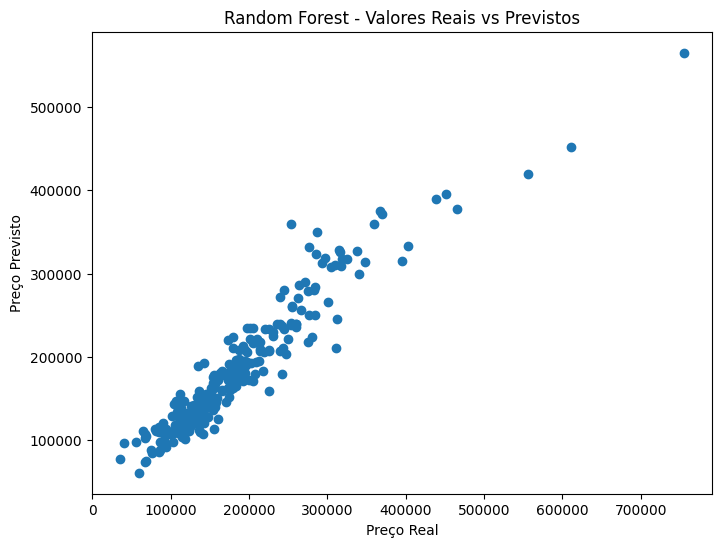

In [29]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Random Forest - Valores Reais vs Previstos')
plt.show()

### Análise Visual das Previsões

O gráfico de dispersão entre os valores reais e os valores previstos pelo modelo Random Forest demonstra um bom alinhamento entre as previsões e os preços observados no conjunto de teste.

Observa-se que a maior parte dos pontos segue uma tendência aproximadamente linear, indicando que o modelo conseguiu capturar adequadamente os padrões presentes nos dados. Quanto mais próximo um ponto estiver da diagonal imaginária entre os eixos, menor é o erro de previsão correspondente.

Embora existam alguns desvios, principalmente entre imóveis de maior valor, o comportamento geral do gráfico reforça os resultados obtidos pelas métricas quantitativas, evidenciando a capacidade do modelo em estimar preços de imóveis com boa precisão.


## Discussão dos Resultados

Os resultados obtidos demonstraram que as características presentes no dataset possuem forte capacidade explicativa sobre os preços dos imóveis.

A análise exploratória permitiu identificar variáveis altamente correlacionadas com a variável alvo, especialmente atributos relacionados à qualidade da construção, área habitável e características estruturais dos imóveis. Essas informações foram importantes para compreender os fatores que mais influenciam o valor de mercado das propriedades.

A comparação entre os modelos mostrou diferenças significativas de desempenho. Enquanto a Regressão Linear conseguiu explicar aproximadamente 63,89% da variabilidade dos preços, o modelo Random Forest atingiu um coeficiente de determinação de 89,20%.

Esse resultado sugere que a relação entre as características dos imóveis e seus preços envolve padrões não lineares e interações complexas entre variáveis, aspectos que são capturados com maior eficiência pelo Random Forest.

Apesar do bom desempenho alcançado, algumas limitações permanecem. O dataset representa imóveis de uma única cidade dos Estados Unidos, o que pode limitar a capacidade de generalização do modelo para outros mercados imobiliários. Além disso, não foi realizada otimização de hiperparâmetros, o que indica que melhorias adicionais ainda poderiam ser obtidas.


## Próximos Passos

Como evoluções futuras deste projeto, poderiam ser realizadas:

- Otimização de hiperparâmetros do Random Forest;
- Teste de algoritmos adicionais, como XGBoost e Gradient Boosting;
- Aplicação de validação cruzada;
- Engenharia de atributos;
- Avaliação da importância das variáveis;
- Testes com transformação logarítmica da variável alvo.

## Conclusão

Neste trabalho foi desenvolvido um MVP de Machine Learning com o objetivo de prever preços de imóveis a partir de características físicas, estruturais e locacionais das propriedades.

O projeto seguiu todas as etapas fundamentais de um fluxo de Machine Learning, incluindo análise exploratória dos dados, tratamento de valores ausentes, transformação de variáveis categóricas, preparação dos dados, treinamento dos modelos e avaliação dos resultados.

Os experimentos realizados demonstraram que o modelo Random Forest apresentou desempenho superior à Regressão Linear, alcançando um coeficiente de determinação (R²) de 0,8920 e reduzindo significativamente os erros de previsão.

Os resultados obtidos indicam que a solução desenvolvida é capaz de estimar preços de imóveis com boa precisão, demonstrando a aplicação prática de técnicas de Machine Learning em problemas de regressão supervisionada.

Como trabalhos futuros, poderiam ser exploradas técnicas adicionais de engenharia de atributos, otimização de hiperparâmetros e avaliação de outros algoritmos de regressão para buscar ganhos adicionais de desempenho.
